# Weekly Workflow — BBO Capstone

Slim notebook for each week: load data, fit surrogates, generate queries, format for portal.
Run cells in order. After receiving results, use **data_management.ipynb** to load and update, then return here for the next week.

**Week 10:** 3 queries remaining per function. Conservative exploitation: tightened radii across the board after W9 regressions on F6/F7. Priority: **F7** (recover from overshoot), **F4** (protect new best), F8 (micro-adjust).


## 1. Setup and load data

**Week 10 approach** (conservative exploitation — 3 remaining queries):

- **F1**: Manual `[0.25, 0.75]` — last unexplored quadrant corner.
- **F2**: GP, EI, tighter focus on ridge `[0.70, 0.945]`, radius=0.02.
- **F3**: GP-ARD, EI, tighter focus `[0.384, 0.390, 0.467]`, radius=0.01 (halved from W9).
- **F4**: GP-ARD, EI, tiny perturbation around W9 new best, radius=0.005.
- **F5**: Manual `[0.98, 0.98, 0.98, 1.0]` — probe just inside boundary.
- **F6**: GP-ARD, EI, anchor milk at 0.03 (W9 milk=0.07 regressed), radius=0.015.
- **F7**: GP-ARD, **EI** (switched from UCB), tight radius=0.015 around W8 best (W9 gradient overshoot).
- **F8**: SVR, EI, micro-adjust near W9 new best, radius=0.01.

`initialize_all_weeks` loads every `week_*` folder present (include **week_9** before generating).


In [8]:
import sys
from pathlib import Path
# Allow imports from src when run from notebooks/ or from project root
root = Path.cwd() if (Path.cwd() / "src").exists() else Path.cwd().parent
sys.path.insert(0, str(root))

import numpy as np
from src.data import FunctionData, DATA_DIR, initialize_all_weeks
from src.surrogates import GPSurrogate, SVMSurrogate, MLPSurrogate
from src.acquisition import optimize_acquisition_enhanced, optimize_acquisition_with_regional_focus
from src.utils import format_for_portal, plot_progress, display_competition_summary

np.random.seed(42)
print("✓ Imports ready")
# If you get ImportError for SVMSurrogate/MLPSurrogate: use Kernel → Restart, then run again (clears cached bytecode).

✓ Imports ready


In [9]:
# Load all 8 functions (from data/function_1 .. function_8)
functions = {i: FunctionData(i, data_dir=DATA_DIR) for i in range(1, 9)}
for i, f in functions.items():
    print(f"  {f}")
print("✓ Functions loaded")

  Function 1: 2D, 10 samples, best=0.000000
  Function 2: 2D, 10 samples, best=0.611205
  Function 3: 3D, 15 samples, best=-0.034835
  Function 4: 4D, 30 samples, best=-4.025542
  Function 5: 4D, 20 samples, best=1088.859618
  Function 6: 5D, 20 samples, best=-0.714265
  Function 7: 6D, 30 samples, best=1.364968
  Function 8: 8D, 40 samples, best=9.598482
✓ Functions loaded


In [10]:
# Initialize with all historical weeks (from data/results/week_1, week_2, ...)
num_weeks = initialize_all_weeks(functions)
print(f"✓ Initialized with {num_weeks} weeks of results")

INITIALIZING FUNCTIONS FROM HISTORICAL DATA
Source: /home/robin/Personal_Development/Capstone-Project-ML-AI-Imperial-College/public/data/results
Loading weeks: [1, 2, 3, 4, 5, 6, 7, 8]

✓ Loaded Week 1 from /home/robin/Personal_Development/Capstone-Project-ML-AI-Imperial-College/public/data/results/week_1
✓ Week 1: Updated 8 functions
✓ Loaded Week 2 from /home/robin/Personal_Development/Capstone-Project-ML-AI-Imperial-College/public/data/results/week_2
✓ Week 2: Updated 8 functions
✓ Loaded Week 3 from /home/robin/Personal_Development/Capstone-Project-ML-AI-Imperial-College/public/data/results/week_3
✓ Week 3: Updated 8 functions
✓ Loaded Week 4 from /home/robin/Personal_Development/Capstone-Project-ML-AI-Imperial-College/public/data/results/week_4
✓ Week 4: Updated 8 functions
✓ Loaded Week 5 from /home/robin/Personal_Development/Capstone-Project-ML-AI-Imperial-College/public/data/results/week_5
✓ Week 5: Updated 8 functions
✓ Loaded Week 6 from /home/robin/Personal_Development/Capst

## 2. Week-specific strategies

1. Run **`llm_experiments.ipynb`** (optional but required for W8 reflection data): logs prompts, temperatures, and parsed queries to `data/results/week_8/llm_experiments.json`.
2. Edit the `strategies` dict in the next cell if you override with LLM consensus or manual probes.
3. Run **Section 3** to generate `queries`, then **Section 4** for portal formatting.


### LLM experiment summary (fill after running `llm_experiments.ipynb`)

- **Provider / model:** _e.g. OpenAI gpt-4o-mini_
- **Parse success rate:** _from analysis cell_
- **Temperature trade-off:** _coherence vs diversity (coord std)_
- **Domain context on vs off:** _did suggestions shift materially?_
- **Agreement with surrogate:** _L2 distances from agreement cell_


In [ ]:
# Week 10 strategies — conservative exploitation after W9 regressions on F6/F7.
# 3 queries remaining per function after this submission.
CURRENT_WEEK = 10

# F1: last unexplored quadrant corner (covered: centre, east, SW, NE)
f1_manual = np.array([0.25, 0.75])

# F2: tighten around W4 best ridge; push x1 toward 0.945 (W9 at 0.92 was too low)
f2_focus = np.array([0.700, 0.945])

# F3: halved radius (0.015->0.01); W9 overshot at [0.369,...]. Stay near W5/W8 peak.
f3_focus = np.array([0.384, 0.390, 0.467])

# F4: W9 new best at [0.417, 0.409, 0.355, 0.427]. Tiny surrogate perturbation.
f4_focus = np.array([0.417, 0.409, 0.355, 0.427])

# F5: solved and deterministic. One probe just inside boundary to map gradient.
f5_manual = np.array([0.98, 0.98, 0.98, 1.0])

# F6: W9 milk=0.07 regressed badly. Anchor milk at 0.03 (W6 level), stay near W8 best.
f6_focus = np.array([0.248, 0.281, 0.412, 0.791, 0.03])

# F7: abandon gradient hypothesis. EI (not UCB), tight radius around W8 best.
f7_focus = np.array([0.158, 0.156, 0.474, 0.184, 0.307, 0.756])

# F8: W9 new best. Continue micro-adjustments with tighter radius.
f8_focus = np.array([0.112, 0.246, 0.099, 0.167, 0.821, 0.379, 0.171, 0.548])

strategies = {
    1: {"manual_query": f1_manual},
    2: {"surrogate": "gp", "gp_noise": 0.05, "acq_func": "ei", "xi": 0.003, "use_regional_focus": True, "focus_region": f2_focus, "focus_radius": 0.02, "n_random": 2000},
    3: {"surrogate": "gp", "use_ard": True, "acq_func": "ei", "xi": 0.0003, "use_regional_focus": True, "focus_region": f3_focus, "focus_radius": 0.01, "n_random": 2000},
    4: {"surrogate": "gp", "use_ard": True, "acq_func": "ei", "xi": 0.0002, "use_regional_focus": True, "focus_region": f4_focus, "focus_radius": 0.005, "n_random": 3000},
    5: {"manual_query": f5_manual},
    6: {"surrogate": "gp", "use_ard": True, "acq_func": "ei", "xi": 0.001, "use_regional_focus": True, "focus_region": f6_focus, "focus_radius": 0.015, "n_random": 2000},
    7: {"surrogate": "gp", "use_ard": True, "acq_func": "ei", "xi": 0.001, "use_regional_focus": True, "focus_region": f7_focus, "focus_radius": 0.015, "n_random": 10000},
    8: {"surrogate": "svr", "svr_C": 5.0, "svr_epsilon": 0.15, "svr_n_bootstrap": 40, "acq_func": "ei", "xi": 0.001, "use_regional_focus": True, "focus_region": f8_focus, "focus_radius": 0.01, "n_random": 20000},
}
print(f"✓ Strategies set for Week {CURRENT_WEEK}")


✓ Strategies set for Week 9


## 3. Generate queries

In [12]:
def _make_surrogate(surrogate_key: str, func_data, strategy: dict):
    key = surrogate_key.lower()
    if key == "gp":
        use_ard = strategy.get("use_ard", False)
        noise = strategy.get("gp_noise", 1e-5)
        return GPSurrogate(length_scale=0.5, optimize=True, noise=noise, use_ard=use_ard)
    if key == "svr":
        return SVMSurrogate(
            C=strategy.get("svr_C", 10.0),
            epsilon=strategy.get("svr_epsilon", 0.1),
            n_bootstrap=strategy.get("svr_n_bootstrap", 20),
        )
    if key == "mlp":
        return MLPSurrogate(hidden_sizes=(64, 32), dropout=0.1, n_mc_samples=50)
    return GPSurrogate(length_scale=0.5, optimize=True)

queries = {}
surrogates = {}

for func_id in range(1, 9):
    func_data = functions[func_id]
    s = strategies.get(func_id, {"acq_func": "ucb", "beta": 2.0})
    if "manual_query" in s:
        x = np.asarray(s["manual_query"], dtype=float)
        queries[func_id] = x
        surrogates[func_id] = None
        print(f"  F{func_id}: MANUAL → x = {np.array2string(x, precision=4, separator=', ')}")
        continue
    surrogate_key = s.get("surrogate", "gp")
    surrogate = _make_surrogate(surrogate_key, func_data, s)
    surrogate.fit(func_data.inputs, func_data.outputs)
    acq_func = s.get("acq_func", "ucb")
    acq_params = {k: v for k, v in s.items() if k in ("beta", "xi")}
    if s.get("use_regional_focus") and s.get("focus_region") is not None:
        x, mu, sigma = optimize_acquisition_with_regional_focus(
            surrogate, func_data, acq_func=acq_func,
            focus_region=s["focus_region"], focus_radius=s.get("focus_radius", 0.15),
            n_random=s.get("n_random", 1000), expand_search=s.get("expand_search", True),
            random_state=42,
            **acq_params
        )
    else:
        x, mu, sigma = optimize_acquisition_enhanced(
            surrogate, func_data, acq_func=acq_func,
            n_random=s.get("n_random", 1000), **acq_params
        )
    queries[func_id] = x
    surrogates[func_id] = surrogate
    print(f"  F{func_id}: {acq_func.upper()} → x = {np.array2string(x, precision=4, separator=', ')}")

print("✓ Queries generated")

  F1: MANUAL → x = [0.75, 0.75]
  F2: EI → x = [0.7259, 0.92  ]


/home/robin/Personal_Development/Capstone-Project-ML-AI-Imperial-College/venv/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


  F3: EI → x = [0.3692, 0.3833, 0.4731]
  F4: MANUAL → x = [0.417, 0.409, 0.355, 0.427]
  F5: MANUAL → x = [1., 1., 1., 1.]
  F6: EI → x = [0.208 , 0.258 , 0.402 , 0.7942, 0.07  ]


/home/robin/Personal_Development/Capstone-Project-ML-AI-Imperial-College/venv/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 2 of parameter k2__length_scale is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


  F7: UCB → x = [0.1247, 0.116 , 0.514 , 0.144 , 0.267 , 0.7591]
  F8: EI → x = [0.1118, 0.246 , 0.0991, 0.167 , 0.821 , 0.379 , 0.171 , 0.548 ]
✓ Queries generated


## 4. Format and submit

In [13]:
format_for_portal(queries, title=f"WEEK {CURRENT_WEEK} QUERIES — READY FOR SUBMISSION")

╔==============================================================================╗
║                    WEEK 9 QUERIES — READY FOR SUBMISSION                     ║
╠==============================================================================╣
║ Function 1: 0.750000-0.750000                                                ║
║ Function 2: 0.725915-0.920000                                                ║
║ Function 3: 0.369219-0.383341-0.473112                                       ║
║ Function 4: 0.417000-0.409000-0.355000-0.427000                              ║
║ Function 5: 0.999999-0.999999-0.999999-0.999999                              ║
║ Function 6: 0.208000-0.258000-0.402000-0.794230-0.070000                     ║
║ Function 7: 0.124742-0.116000-0.514000-0.144000-0.267000-0.759092            ║
║ Function 8: 0.111776-0.246000-0.099084-0.167000-0.821000-0.379000-0.171000-0.548000 ║
╚==============================================================================╝

✓ Copy the formatted

## 5. Optional: view progress

COMPETITION SUMMARY
Total weekly submissions: 0
Best values by function:
--------------------------------------------------------------------------------
Function 1 (2D): 0.000000 (+0.000000, 18 samples)
Function 2 (2D): 0.620709 (+0.081713, 18 samples)
Function 3 (3D): -0.005532 (+0.106591, 23 samples)
Function 4 (4D): 0.661171 (+22.769458, 38 samples)
Function 5 (4D): 8662.405001 (+8597.961561, 28 samples)
Function 6 (5D): -0.474483 (+0.239782, 28 samples)
Function 7 (6D): 2.836284 (+2.231852, 38 samples)
Function 8 (8D): 9.967695 (+2.568974, 48 samples)


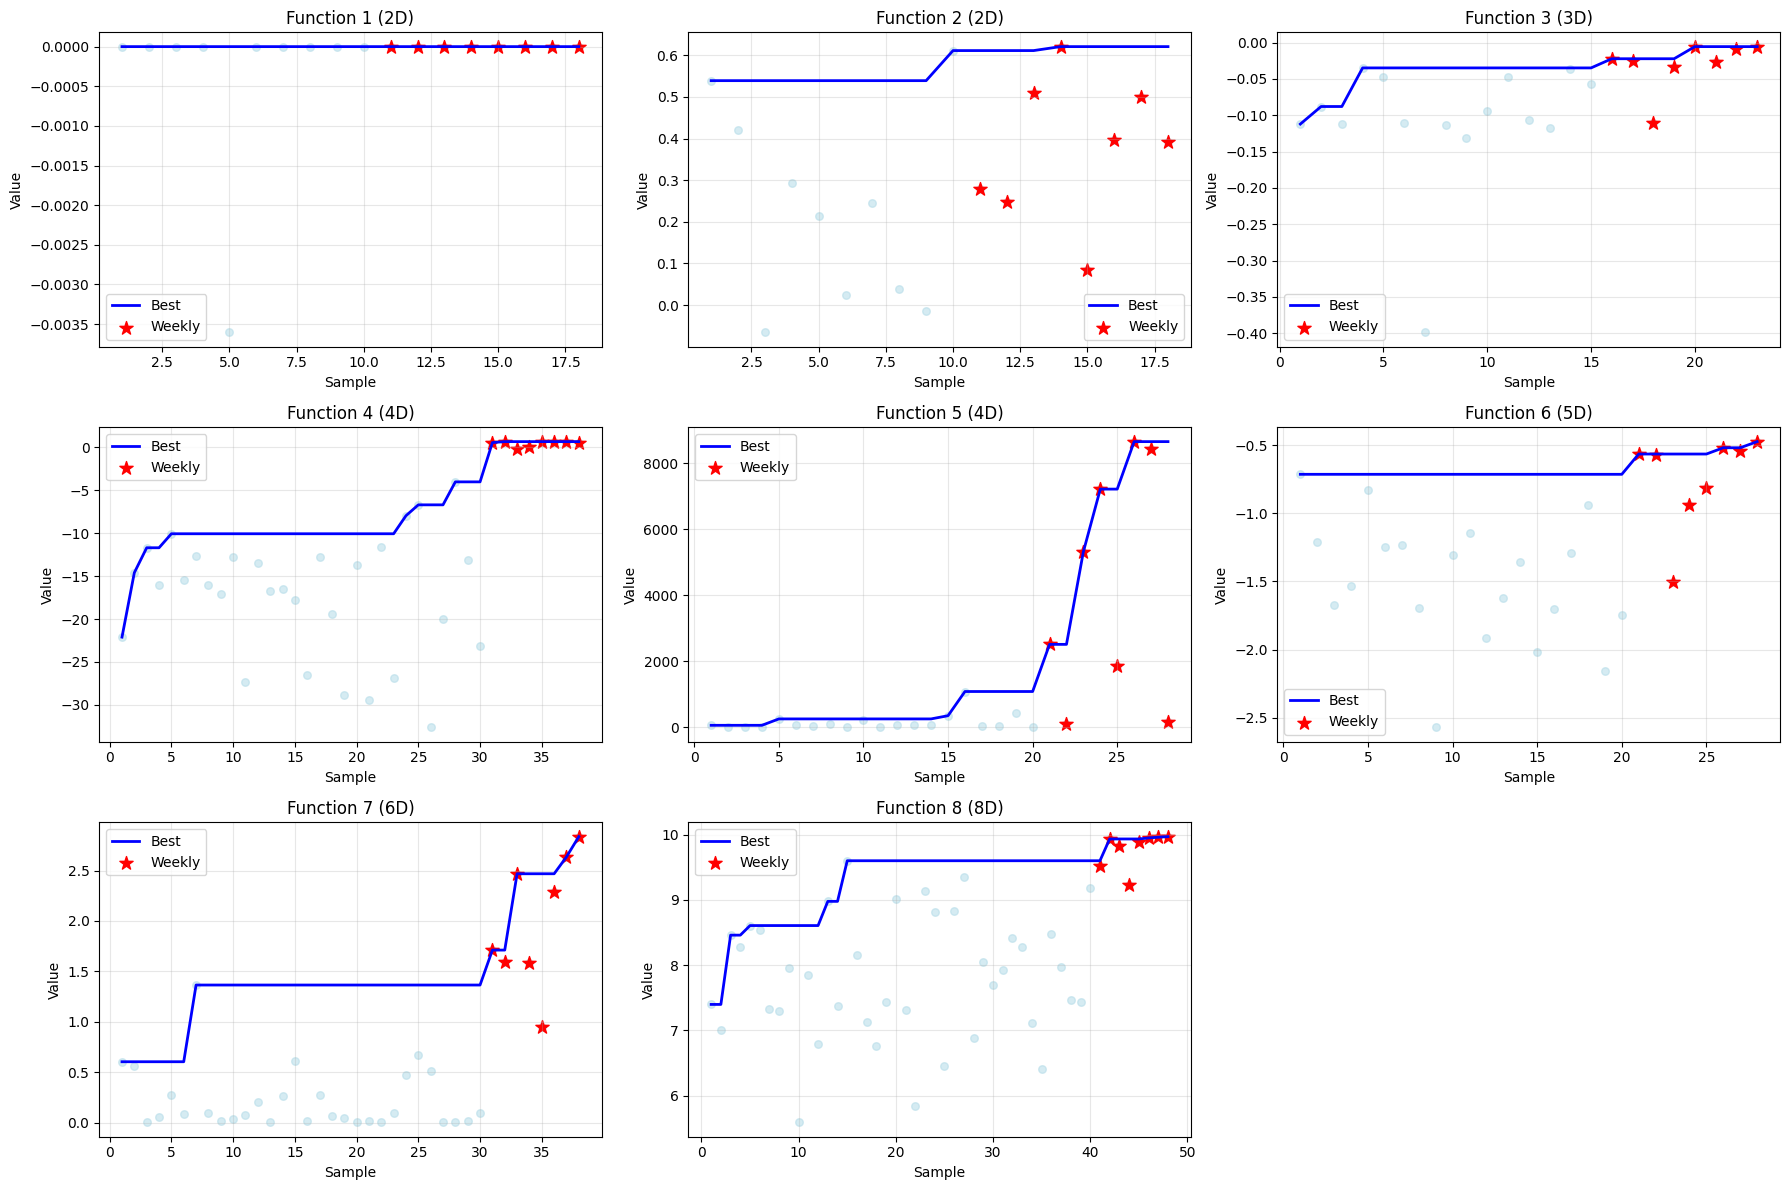

In [14]:
display_competition_summary(functions)
plot_progress(functions)